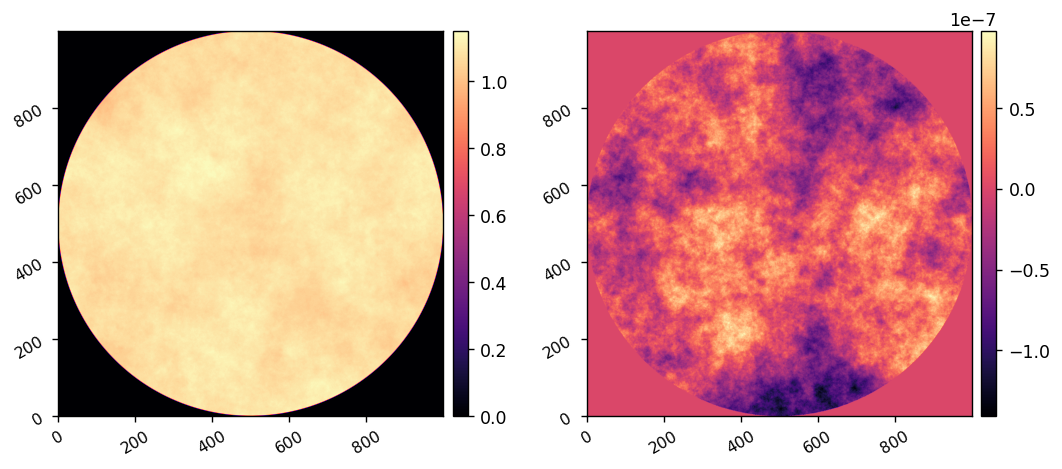

In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import iefc
import scoob_llowfsc.scoob_model as scoobm

# import poppy
# import logging, sys
# poppy_log = logging.getLogger('poppy')
# poppy_log.setLevel('DEBUG')
# logging.basicConfig(stream=sys.stdout, level=logging.INFO)
# poppy_log.disabled = True

wfe_amp = utils.load_fits('example_wfe_amp.fits')
wfe_opd = utils.load_fits('example_wfe_opd.fits')
imshow2(wfe_amp, wfe_opd)




Oversampling > 2x suggested for reliable results in Fresnel propagation.


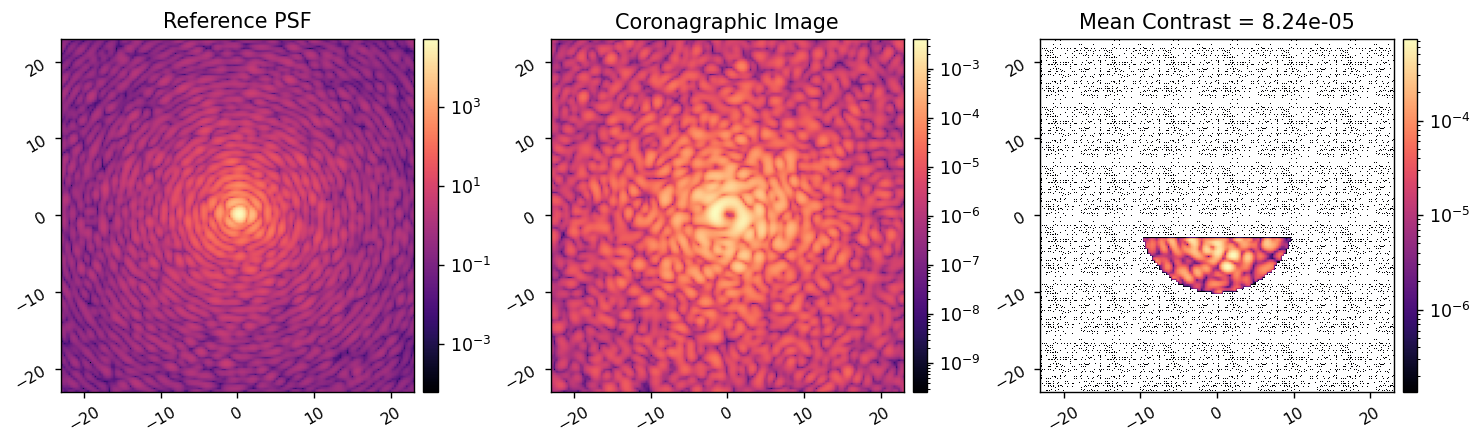

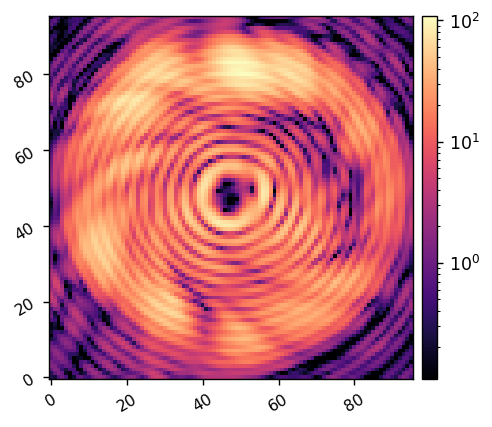

In [61]:
reload(scoobm)
reload(utils)

M = scoobm.single(
    # dm_ref=dm_flat,
)
M.AMP = wfe_amp
M.OPD = wfe_opd 

iwa = 3
owa = 10
control_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im0 = M.snap_camsci()
mean_contrast = xp.mean(camsci_im0[control_mask])

imshow3(
    ref_psf, camsci_im0, camsci_im0*control_mask,
    'Reference PSF', 'Coronagraphic Image', f'Mean Contrast = {mean_contrast:.2e}', 
    pxscl=M.camsci_pxscl_lamDc,
    lognorm=1, 
)

M.llowfsc_defocus = 4.75*u.mm
camlo_im0 = M.snap_camlo()
imshow1(camlo_im0, lognorm=1, vmin=xp.max(camlo_im0)/1e3)

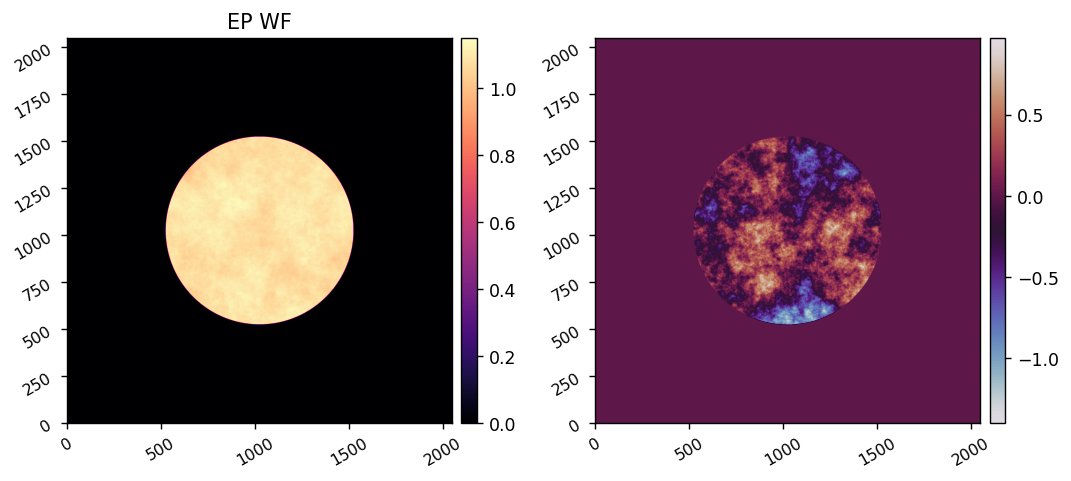

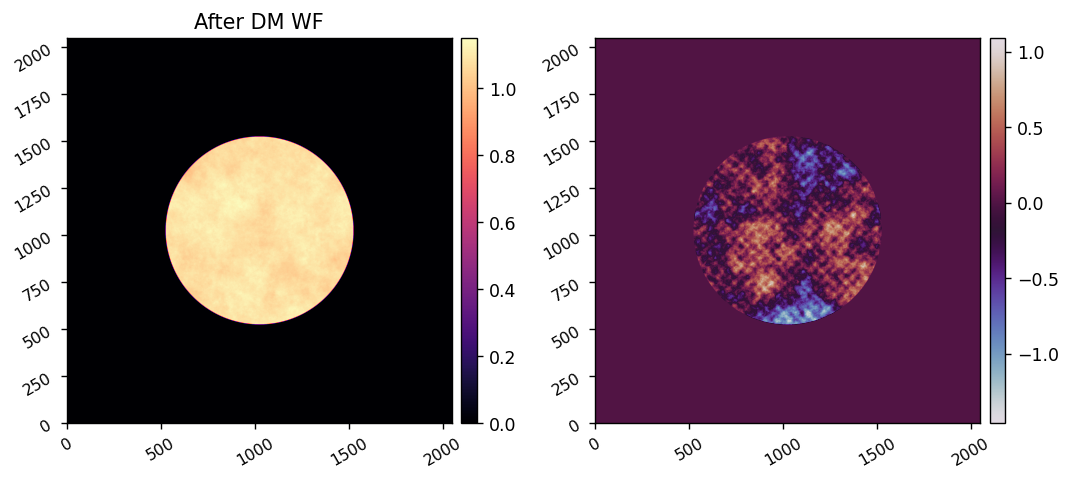

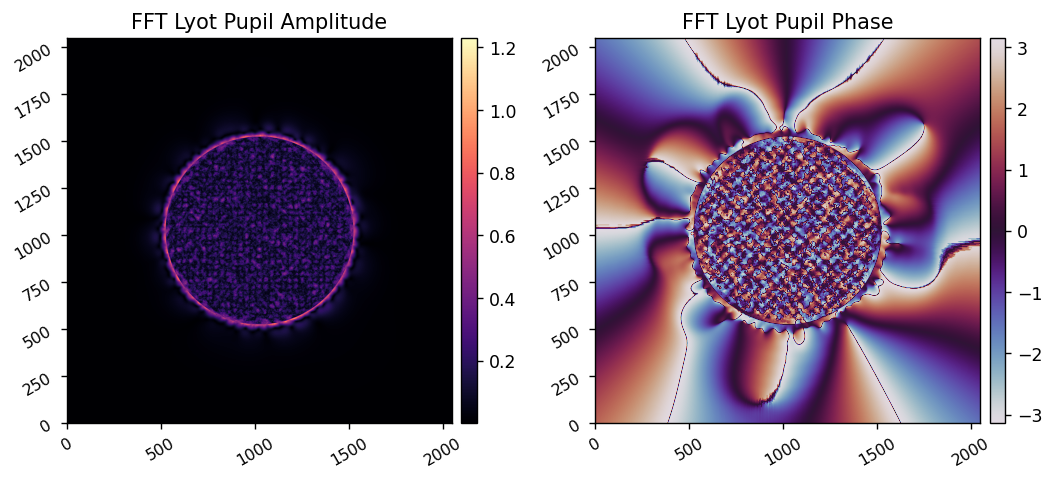

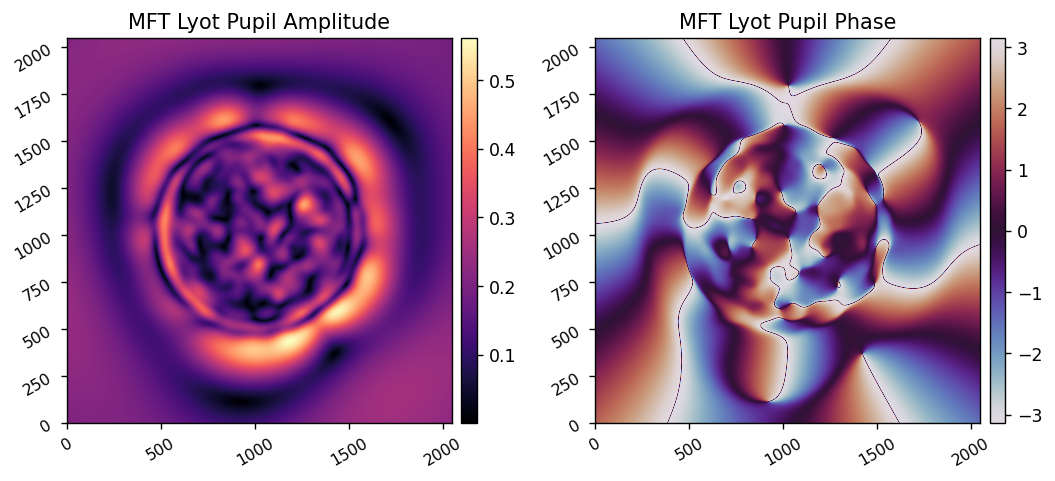

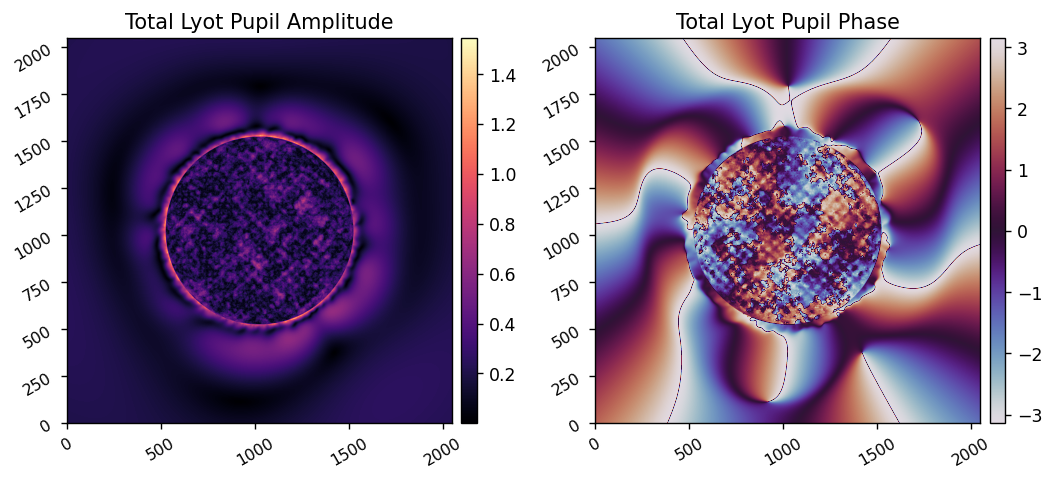

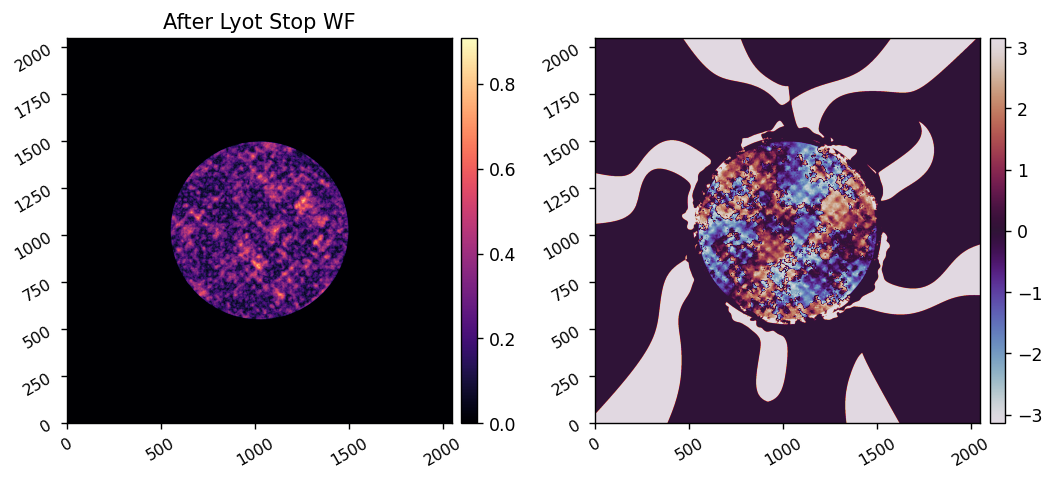

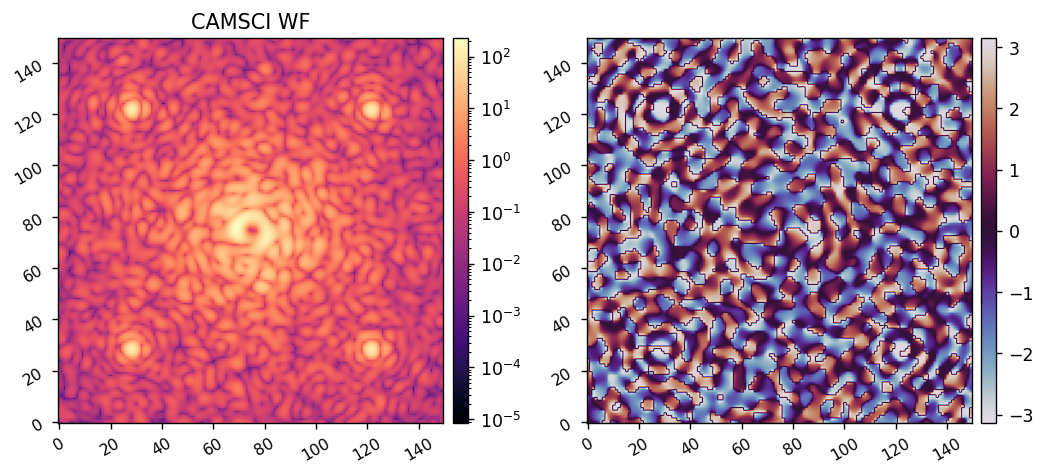

In [59]:
reload(utils)
M.plot_oversample = 2.048

M.AMP, M.OPD = ( wfe_amp, wfe_opd )
# M.AMP, M.OPD = ( xp.ones_like(M.APERTURE), xp.zeros_like(M.APERTURE) )

M.reset_dm()

waffle_command = 20e-9 * utils.make_fourier_command(x_cpa=17, y_cpa=17, Nact=M.Nact)
M.dm_command = waffle_command

E_EP, DM_PHASOR, E_DM, E_LP, E_LS, E_CAMSCI = M.calc_wfs_camsci(plot=1)

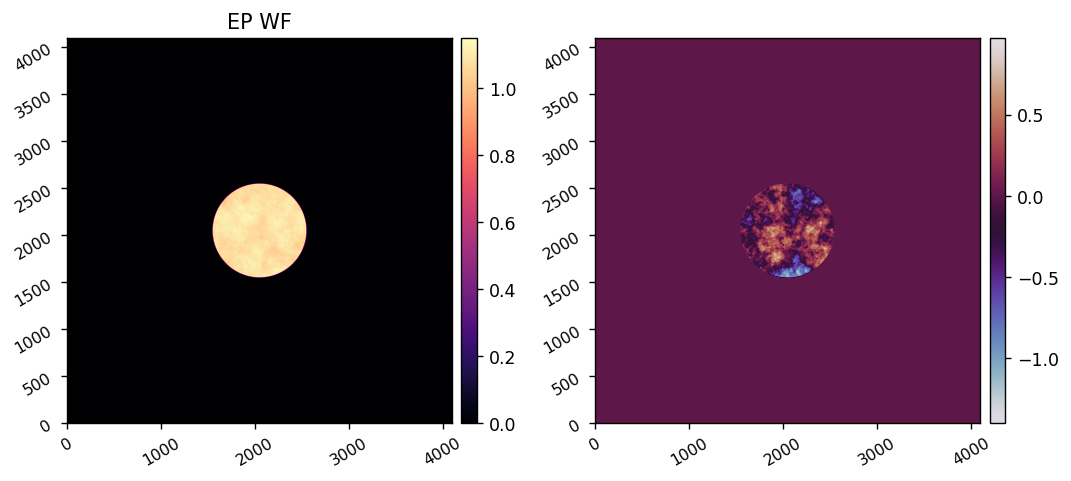

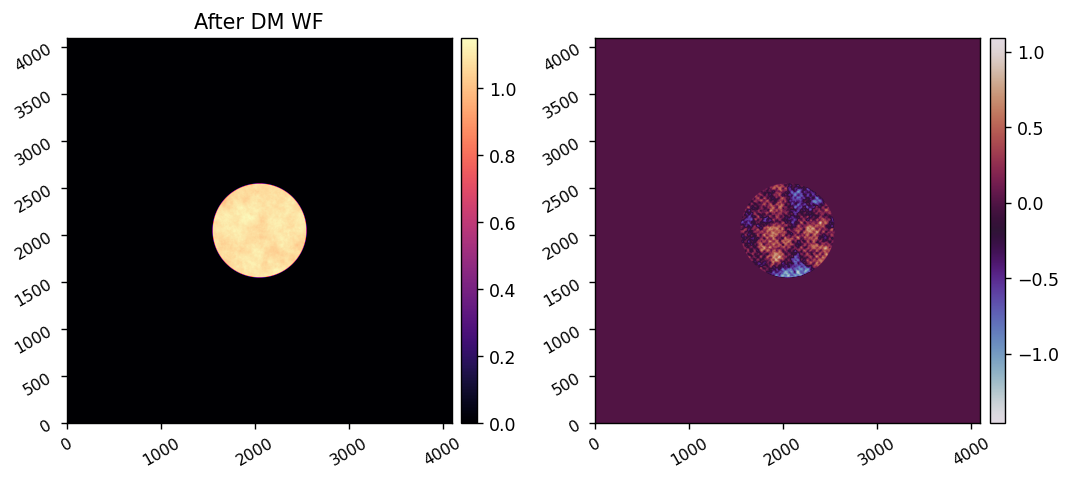

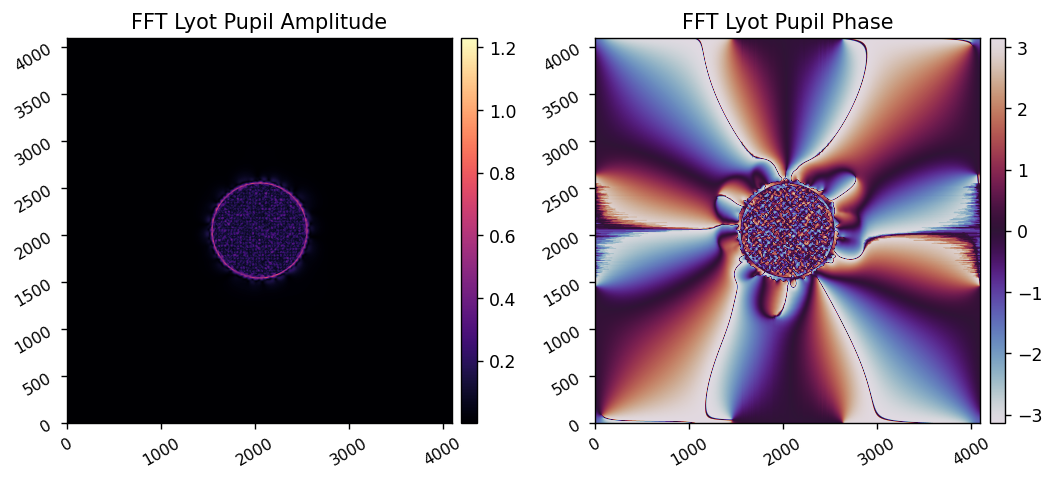

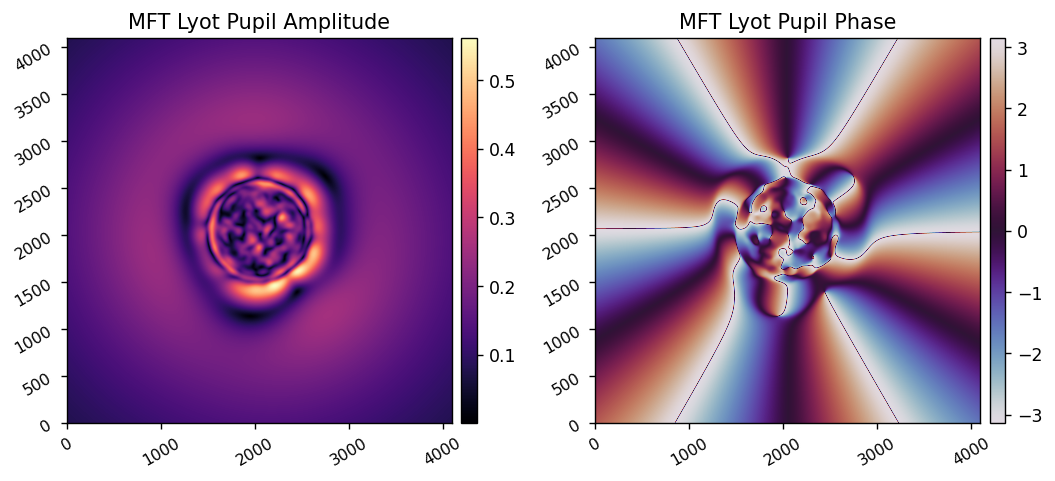

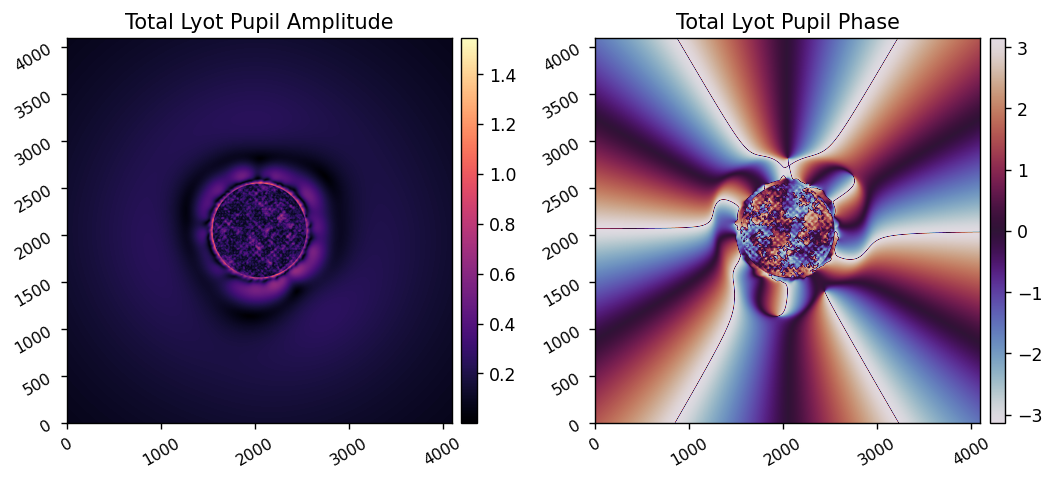

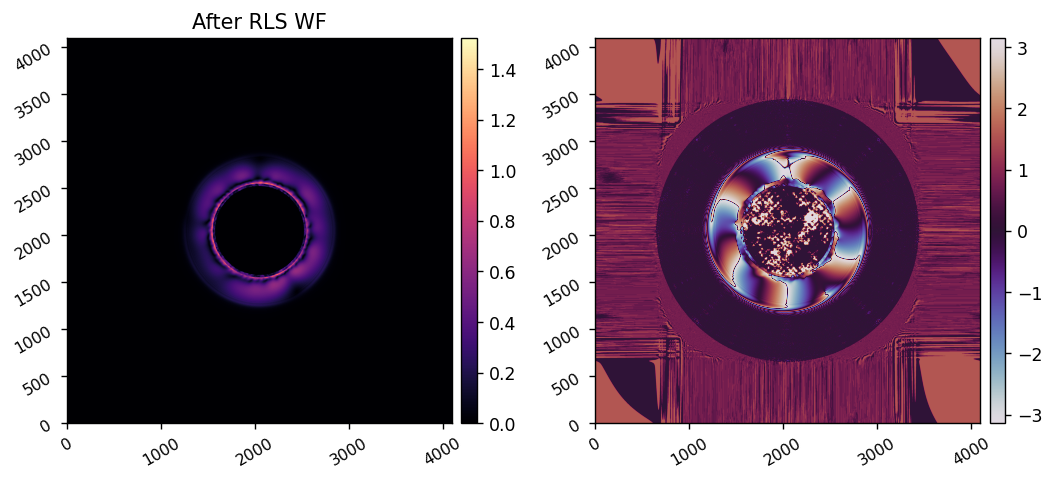

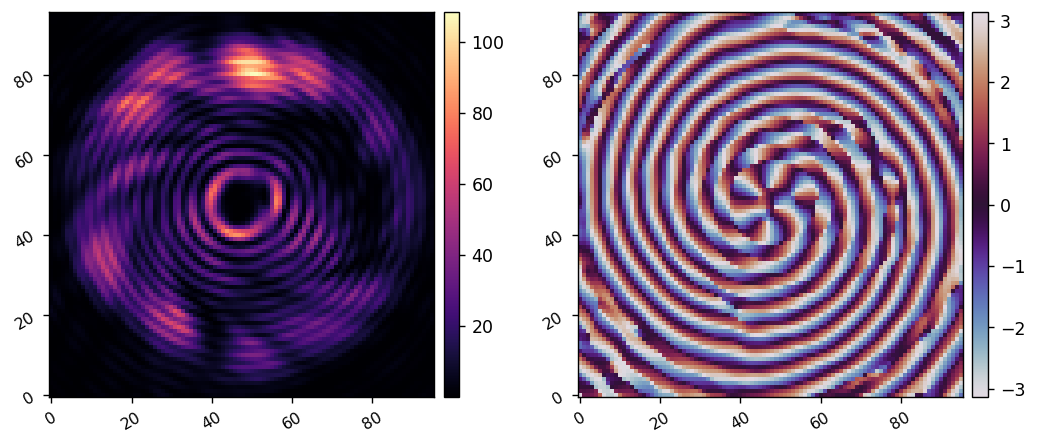

In [60]:
M.plot_oversample = 4.096

M.AMP, M.OPD = ( wfe_amp, wfe_opd )
# M.AMP, M.OPD = ( xp.ones_like(M.APERTURE), xp.zeros_like(M.APERTURE) )

M.reset_dm()

waffle_command = 20e-9 * utils.make_fourier_command(x_cpa=17, y_cpa=17, Nact=M.Nact)
M.dm_command = waffle_command

E_EP, DM_PHASOR, E_DM, E_LP, E_RLS, E_CAMLO = M.calc_wfs_camlo(plot=1)




